# Used Device Data

This is a dataset from Kaggle and the purpose of this project is predict prices for used phones and tablets devices.
* Dataset: [Used Phones & Tables Pricing Dataset](https://www.kaggle.com/datasets/ahsan81/used-handheld-device-data/code)

Columns description:
- **device_brand**: Name of manufacturing brand
- **os**: OS on which the device runs
- **screen_size**: Size of the screen in cm
- **4g**: Whether 4G is available or not
- **5g**: Whether 5G is available or not
- **front_camera_mp**: Resolution of the rear camera in megapixels
- **back_camera_mp**: Resolution of the front camera in megapixels
- **internal_memory**: Amount of internal memory (ROM) in GB
- **ram**: Amount of RAM in GB
- **battery**: Energy capacity of the device battery in mAh
- **weight**: Weight of the device in grams
- **release_year**: Year when the device model was released
- **days_used**: Number of days the used/refurbished device has been used
- **normalized_new_price**: Normalized price of a new device of the same model
- **normalized_used_price** (TARGET): Normalized price of the used/refurbished device

Useful links:
- https://www.kaggle.com/code/erigor/predicting-used-phones-lasso-linearregression
- https://github.com/Krupique/challenges-kaggle/tree/main/challenges/02_HousePricesCompetition
- https://github.com/Krupique/mlops-projects/tree/main/00-tips_ml_solution
- https://github.com/Krupique/mlops-projects/blob/main/00-tips_ml_solution/best_plots.jpeg

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Basic EDA

In [2]:
df_raw = pd.read_csv('raw_data/used_device_data.csv')

In [9]:
print(df_raw.shape)

(3454, 15)


The dataset has 3454 rows with 15 colums. This is few when we talk about big data, so ML models that were designed to work with bigdata might not be good options. But, small models may work well.

In [10]:
display(df_raw.head())

display(df_raw.info())

,device_brand,os,screen_size,4g,5g,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   device_brand           3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   rear_camera_mp         3275 non-null   float64
 6   front_camera_mp        3452 non-null   float64
 7   internal_memory        3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

None

Taking a glance on the dataset, we realize that there are numeric, boolean and categorical features and the numerical ones have different magnitudes.

In [11]:
df_raw.isnull().sum()

device_brand               0
os                         0
screen_size                0
4g                         0
5g                         0
rear_camera_mp           179
front_camera_mp            2
internal_memory            4
ram                        4
battery                    6
weight                     7
release_year               0
days_used                  0
normalized_used_price      0
normalized_new_price       0
dtype: int64

We can see that there are some missing values. In the future we are going to explore more about each missing value feature in order to make the decision if we are going to remove these values or to fill with missing values.

In [13]:
df_raw.describe()

,screen_size,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
count,3454.000000,3275.000000,3452.000000,3450.000000,3450.000000,3448.000000,3447.000000,3454.000000,3454.000000,3454.000000,3454.000000
mean,13.713115,9.460208,6.554229,54.573099,4.036122,3133.402697,182.751871,2015.965258,674.869716,4.364712,5.233107
std,3.805280,4.815461,6.970372,84.972371,1.365105,1299.682844,88.413228,2.298455,248.580166,0.588914,0.683637
min,5.080000,0.080000,0.000000,0.010000,0.020000,500.000000,69.000000,2013.000000,91.000000,1.536867,2.901422
25%,12.700000,5.000000,2.000000,16.000000,4.000000,2100.000000,142.000000,2014.000000,533.500000,4.033931,4.790342
50%,12.830000,8.000000,5.000000,32.000000,4.000000,3000.000000,160.000000,2015.500000,690.500000,4.405133,5.245892
75%,15.340000,13.000000,8.000000,64.000000,4.000000,4000.000000,185.000000,2018.000000,868.750000,4.755700,5.673718
max,30.710000,48.000000,32.000000,1024.000000,12.000000,9720.000000,855.000000,2020.000000,1094.000000,6.619433,7.847841


## EDA (Looking into the columns)
Let's start exploring all columns individually to see what we have

In [15]:
df_raw.columns

Index(['device_brand', 'os', 'screen_size', '4g', '5g', 'rear_camera_mp',
       'front_camera_mp', 'internal_memory', 'ram', 'battery', 'weight',
       'release_year', 'days_used', 'normalized_used_price',
       'normalized_new_price'],
      dtype='object')

### 

### Device Brand (device_brand): Name of manufacturing brand

In [16]:
df_raw.device_brand.head()

0    Honor
1    Honor
2    Honor
3    Honor
4    Honor
Name: device_brand, dtype: object

In [19]:
df_raw['device_brand'].value_counts()[0:15]

device_brand
Others      502
Samsung     341
Huawei      251
LG          201
Lenovo      171
ZTE         140
Xiaomi      132
Oppo        129
Asus        122
Alcatel     121
Micromax    117
Vivo        117
Honor       116
HTC         110
Nokia       106
Name: count, dtype: int64

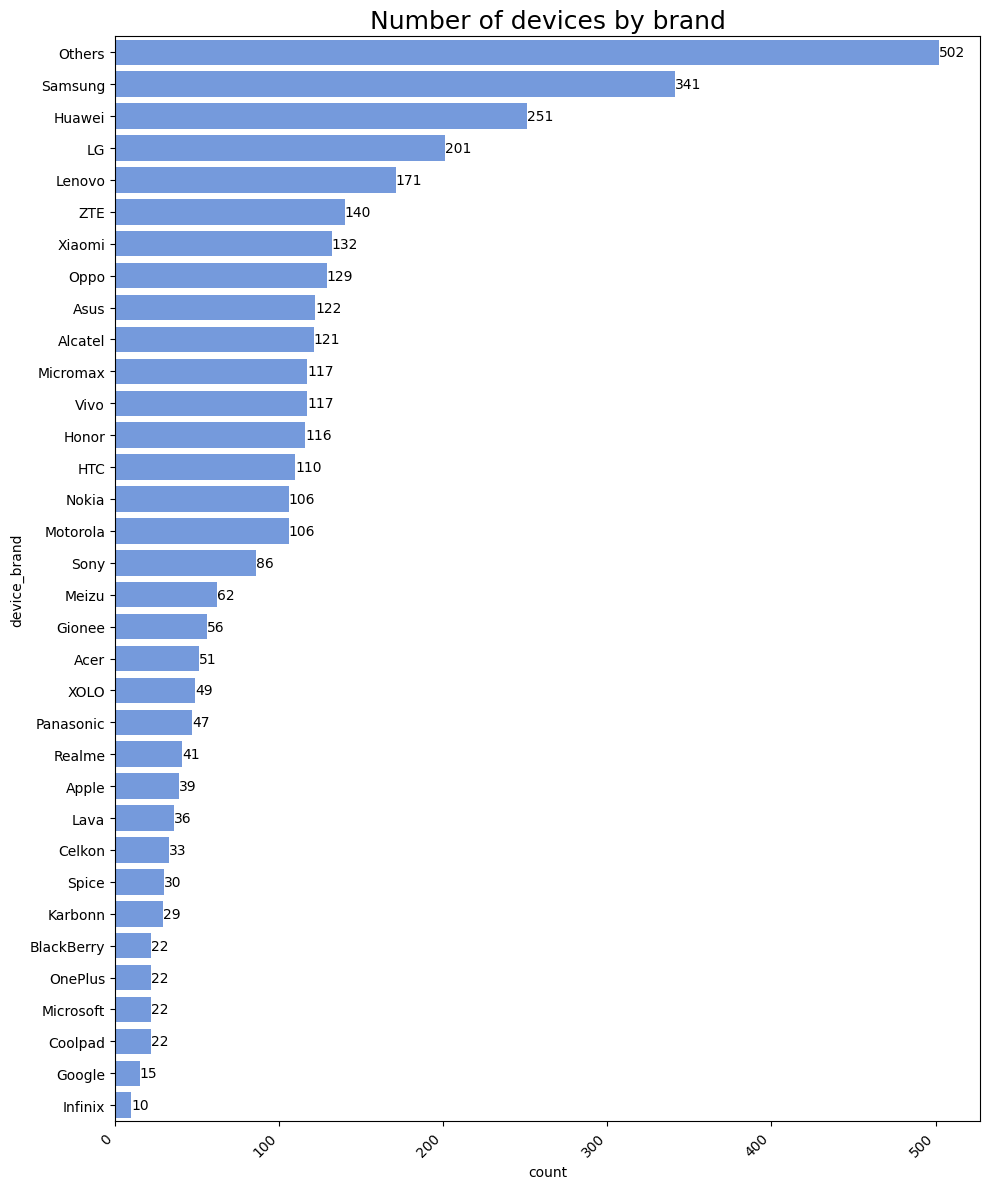

In [ ]:
plt.figure(figsize=(10, 12))

order = df_raw["device_brand"].value_counts().index

ax = sns.countplot(
    data=df_raw,
    y="device_brand",
    order=order,
    color="cornflowerblue"
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45, ha="right")
plt.title("Number of devices by brand", fontsize=18)

plt.tight_layout()
plt.show()

There are a lot of brands in our dataset. And furthermore, the most part of our dataset has others as brand. Maybe this not be a good column to our model.

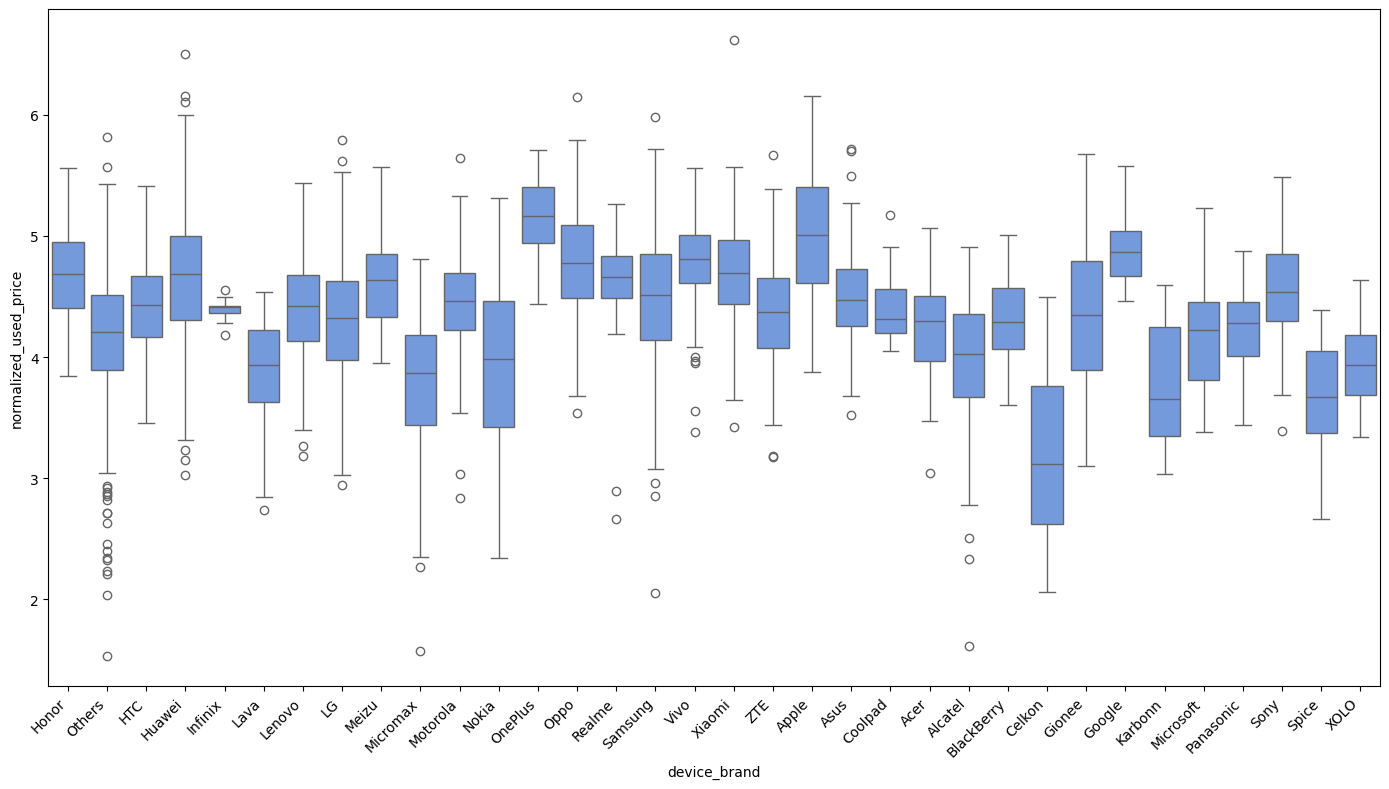

In [38]:
plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df_raw,
    x="device_brand",
    y="normalized_used_price",
    color="cornflowerblue"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

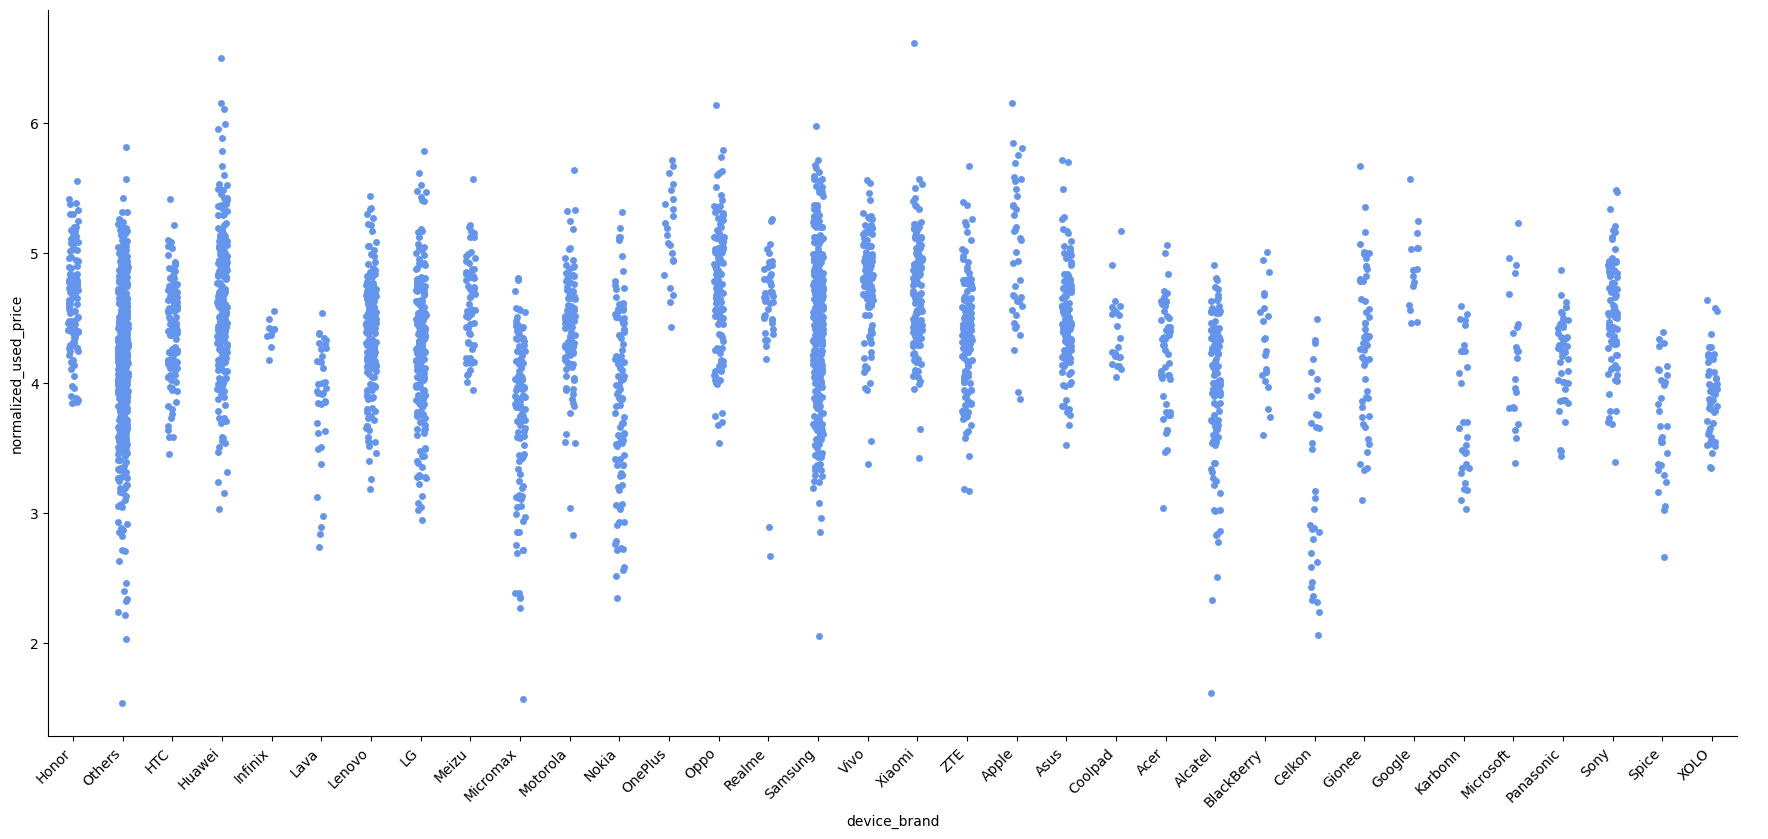

In [41]:
g = sns.catplot(
    data=df_raw,
    x="device_brand",
    y="normalized_used_price",
    height=8,
    aspect=2.2,
    color="cornflowerblue"
)

g.set_xticklabels(rotation=45, ha="right")
g.set_titles("")

plt.show()

Analysing these two plots we can see that there are some correlation between the brand and the final used price. So we can say that in general some brands are better than others for resale. For instance, Apple has a better price for resale.  <br/>
But I believe it depends on the specific model of the smartphone or tablet. In this dataset we don't have the model, but we can estimate better or newer models based on the other columns. 